# Suavizado de punto de interes

(np.float64(-0.5), np.float64(799.5), np.float64(383.5), np.float64(-0.5))

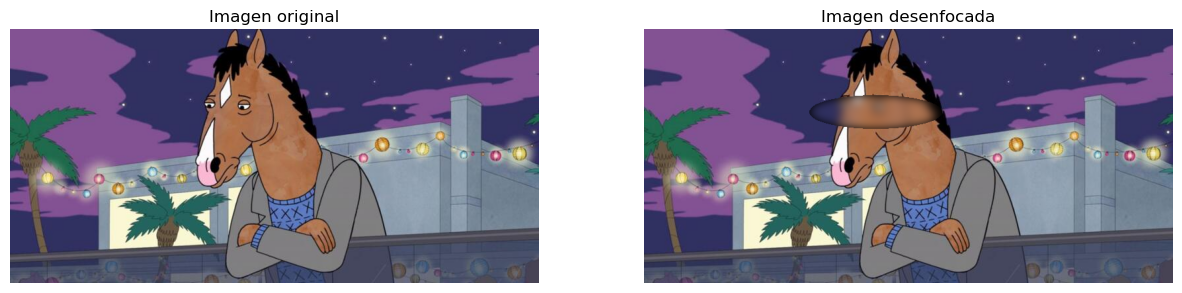

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoqueROI(img, centro, x, y):
  img1 = np.copy(img)
  valx, valy = centro
  mediox = x // 2
  medioy = y // 2
  mascara = np.zeros_like(img, dtype=np.uint8)
  cv2.ellipse(mascara, (valx, valy), (mediox, medioy), 0, 0, 360, (255, 255, 255), -1)
  img_mascara = cv2.bitwise_and(img, mascara)
  # Aumentar el tamaño del kernel para un desenfoque más pronunciado
  desenfoque = cv2.GaussianBlur(img_mascara, (45, 45), 0)
  img1[mascara != 0] = desenfoque[mascara != 0]
  return img1

img = cv2.imread('./images/img1.jpeg')
imagenrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result = desenfoqueROI(imagenrgb, (350, 125), 200, 50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagenrgb)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('Imagen desenfocada')
plt.axis('off')

# Bordes y mascaras

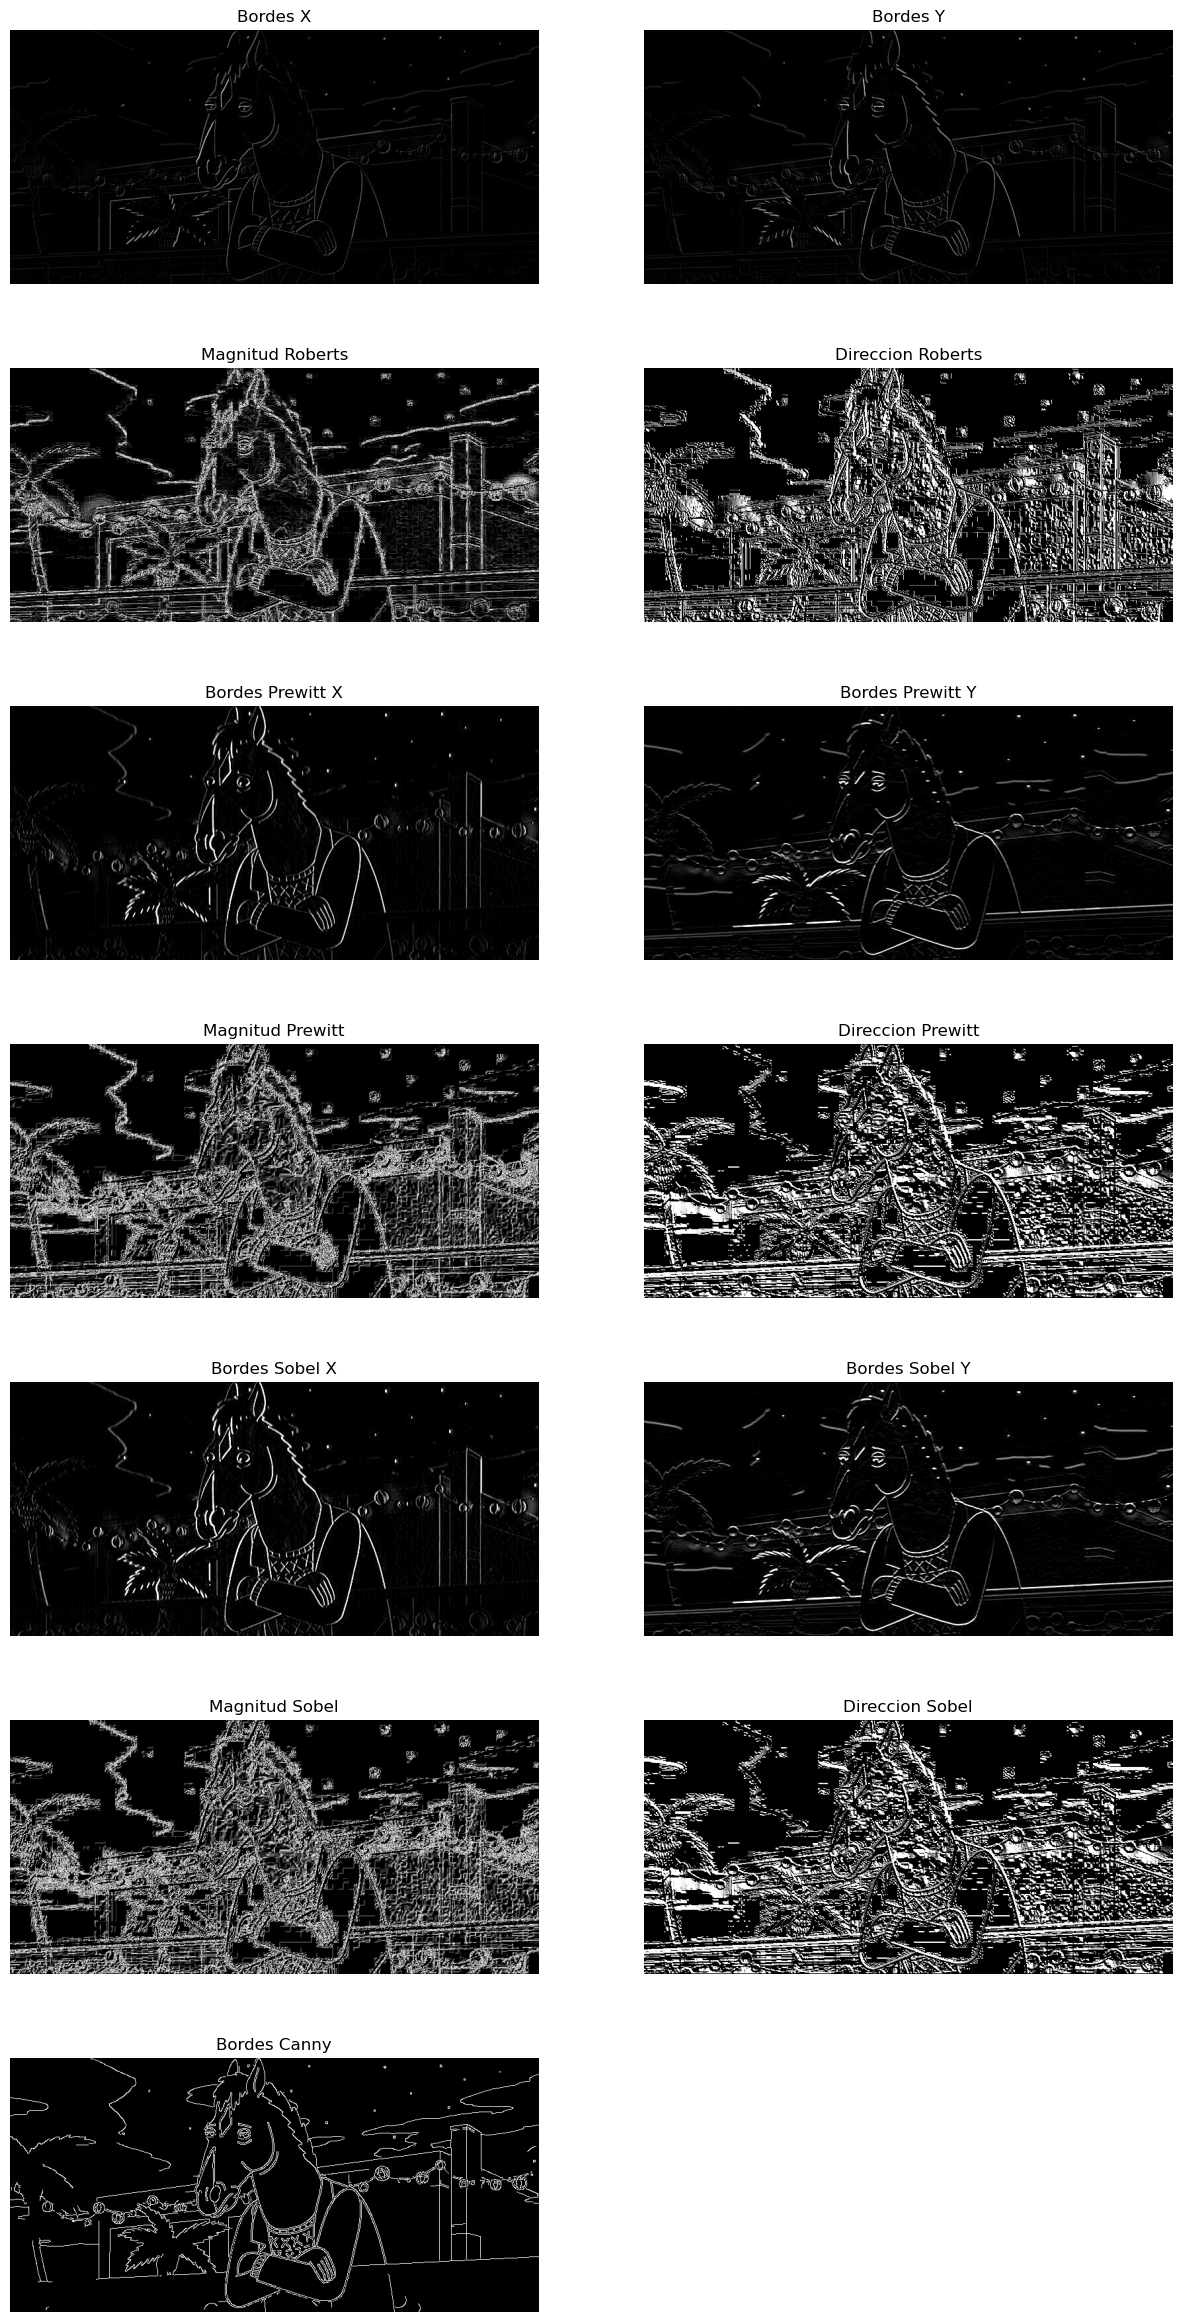

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./images/img1.jpeg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Kernel Roberts
kernel_roberts_x = np.array([[-1, 0],
                             [0, 1]])
kernel_roberts_y = np.array([[0, -1],
                             [1, 0]])

# Aplicar el kernel Roberts
img_bordes_roberts_x = cv2.filter2D(img_gray, -1, kernel_roberts_x)
img_bordes_roberts_y = cv2.filter2D(img_gray, -1, kernel_roberts_y)

# Magnitud en roberts
magnitud_roberts = np.sqrt(img_bordes_roberts_x**2 + img_bordes_roberts_y**2)
direccion_roberts = np.arctan2(img_bordes_roberts_y, img_bordes_roberts_x) # Simulamos aplicar un filtro prewitt

# Filtro prewitt
kernel_prewitt_x = np.array([[1, 0, -1],
                             [1, 0, -1],
                             [1, 0, -1]])
kernel_prewitt_y = np.array([[1, 1, 1],
                             [0, 0, 0],
                             [-1, -1, -1]])

# Aplicar el kernel prewitt
img_bordes_prewitt_x = cv2.filter2D(img_gray, -1, kernel_prewitt_x)
img_bordes_prewitt_y = cv2.filter2D(img_gray, -1, kernel_prewitt_y)

# Magnitud en prewitt
magnitud_prewitt = np.sqrt(img_bordes_prewitt_x**2 + img_bordes_prewitt_y**2)
direccion_prewitt = np.arctan2(img_bordes_prewitt_y, img_bordes_prewitt_x)

# Filtro sobel
kernel_sobel_x = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]])
kernel_sobel_y = np.array([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]])

# Aplicar el kernel sobel
img_bordes_sobel_x = cv2.filter2D(img_gray, -1, kernel_sobel_x)
img_bordes_sobel_y = cv2.filter2D(img_gray, -1, kernel_sobel_y)

# Magnitud en sobel
magnitud_sobel = np.sqrt(img_bordes_sobel_x**2 + img_bordes_sobel_y**2)
direccion_sobel = np.arctan2(img_bordes_sobel_y, img_bordes_sobel_x)

# Filtro canny
img_bordes_canny = cv2.Canny(img_gray, 100, 200)

# Mostrar los bordes
plt.figure(figsize=(15, 30))

plt.subplot(7, 2, 1)
plt.imshow(img_bordes_roberts_x, cmap='gray')
plt.title('Bordes X')
plt.axis('off')

plt.subplot(7, 2, 2)
plt.imshow(img_bordes_roberts_y, cmap='gray')
plt.title('Bordes Y')
plt.axis('off')

plt.subplot(7, 2, 3)
plt.imshow(magnitud_roberts, cmap='gray')
plt.title('Magnitud Roberts')
plt.axis('off')

plt.subplot(7, 2, 4)
plt.imshow(direccion_roberts, cmap='gray')
plt.title('Direccion Roberts')
plt.axis('off')

plt.subplot(7, 2, 5)
plt.imshow(img_bordes_prewitt_x, cmap='gray')
plt.title('Bordes Prewitt X')
plt.axis('off')

plt.subplot(7, 2, 6)
plt.imshow(img_bordes_prewitt_y, cmap='gray')
plt.title('Bordes Prewitt Y')
plt.axis('off')

plt.subplot(7, 2, 7)
plt.imshow(magnitud_prewitt, cmap='gray')
plt.title('Magnitud Prewitt')
plt.axis('off')

plt.subplot(7, 2, 8)
plt.imshow(direccion_prewitt, cmap='gray')
plt.title('Direccion Prewitt')
plt.axis('off')

plt.subplot(7, 2, 9)
plt.imshow(img_bordes_sobel_x, cmap='gray')
plt.title('Bordes Sobel X')
plt.axis('off')

plt.subplot(7, 2, 10)
plt.imshow(img_bordes_sobel_y, cmap='gray')
plt.title('Bordes Sobel Y')
plt.axis('off')

plt.subplot(7, 2, 11)
plt.imshow(magnitud_sobel, cmap='gray')
plt.title('Magnitud Sobel')
plt.axis('off')

plt.subplot(7, 2, 12)
plt.imshow(direccion_sobel, cmap='gray')
plt.title('Direccion Sobel')
plt.axis('off')

plt.subplot(7, 2, 13)
plt.imshow(img_bordes_canny, cmap='gray')
plt.title('Bordes Canny')
plt.axis('off')

plt.show()

# Roberts

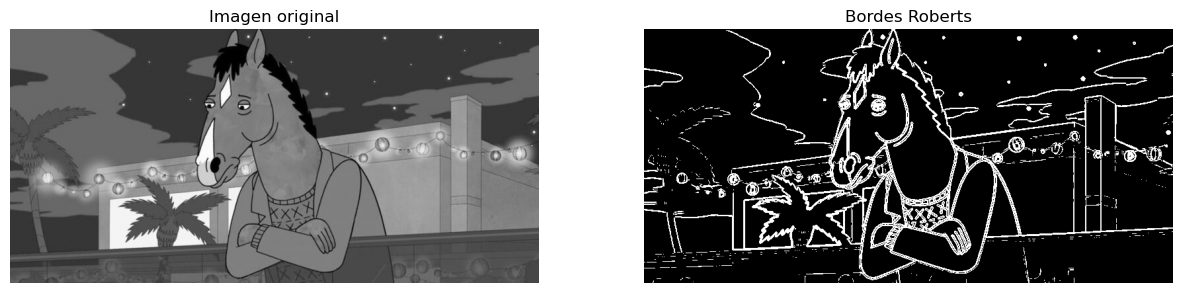

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def roberts_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

  kernel_roberts_x = 2 * np.array([[-1, 0],
                                  [0, 1]])
  kernel_roberts_y = 2 * np.array([[0, -1],
                                  [1, 0]])

  img_bordes_roberts_x = cv2.filter2D(suavizado, cv2.CV_16S, kernel_roberts_x)
  img_bordes_roberts_y = cv2.filter2D(suavizado, cv2.CV_16S, kernel_roberts_y)

  roberts = cv2.addWeighted(np.abs(img_bordes_roberts_x), 0.7, np.abs(img_bordes_roberts_y), 0.7, 0)
  _, bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)
  return bordes

img = cv2.imread('./images/img1.jpeg')
roberts = roberts_mejorado(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(roberts, cmap='gray')
plt.title('Bordes Roberts')
plt.axis('off')

plt.show()

# Sobel

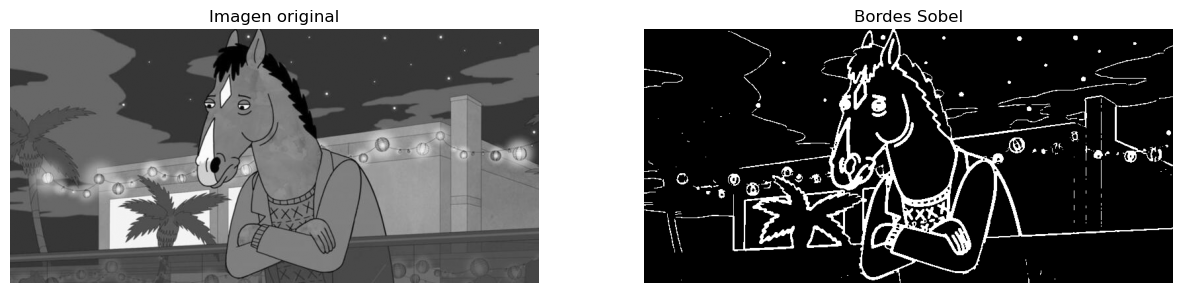

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejorado(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  sobel_x = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
  sobel_y = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
  
  # magnitud = cv2.addWeighted(np.abs(sobel_x), 0.7, np.abs(sobel_y), 0.7, 0)
  magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY) # Agregariamos otsu
  _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Agregariamos otsu

  # Unir bordes rotos
  kernel_morf = np.ones((2, 2), np.uint8)
  bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
  
  return bordes

img = cv2.imread('./images/img1.jpeg')
sobel = sobel_mejorado(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap='gray')
plt.title('Bordes Sobel')
plt.axis('off')

plt.show()

# Prewitt

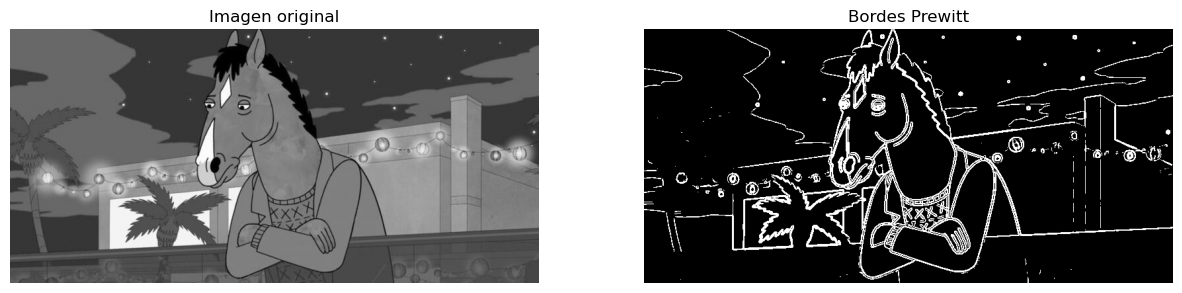

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def prewitt_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  kernel_prewitt_x = 3 * np.array([[1, 0, -1],
                                  [1, 0, -1],
                                  [1, 0, -1]], dtype=np.float32)
  kernel_prewitt_y = 3 * np.array([[1, 1, 1],
                                  [0, 0, 0],
                                  [-1, -1, -1]], dtype=np.float32)
  
  prewitt_x = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_x)
  prewitt_y = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_y)
  
  magnitud = np.sqrt(prewitt_x**2 + prewitt_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
  _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  return bordes

img = cv2.imread('./images/img1.jpeg')
prewitt = prewitt_mejorado(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(prewitt, cmap='gray')
plt.title('Bordes Prewitt')
plt.axis('off')

plt.show()